In [20]:
import numpy as np
import matplotlib.pyplot as plt

import requests
import spacy

import torch

from sklearn.decomposition import PCA

from transformers import GPT2Tokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [2]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Import text

In [3]:
# import Frankenstein text
text = requests.get('https://www.gutenberg.org/cache/epub/84/pg84.txt').text

tokens = tokenizer.encode(text, return_tensors='pt')
unique_tokens = np.unique(tokens)

print(f'There are {len(tokens[0]):,} of which {len(unique_tokens):,} are unique')

There are 114,216 of which 9,242 are unique


In [5]:
# Encode through Spacy
nlp = spacy.load('en_core_web_sm')

doc = nlp(text)

print(f'There are {len(doc):,} tokens in the text of which {len(doc.vocab):,} are unique')

There are 96,083 tokens in the text of which 8,511 are unique


In [6]:
for token in doc[:10]:
    print(f"'{token}' is a {token.pos_}")

'﻿The' is a PUNCT
'Project' is a NOUN
'Gutenberg' is a PROPN
'eBook' is a PROPN
'of' is a ADP
'Frankenstein' is a PROPN
';' is a PUNCT
'or' is a CCONJ
',' is a PUNCT
'the' is a DET


# Group the tokens into batches

In [14]:
batch_size = 150
context_pre = 40
context_pst = 10
window_len = context_pre + context_pst + 1

batch_noun = torch.zeros((batch_size, window_len), dtype=torch.long)
batch_adj  = torch.zeros((batch_size, window_len), dtype=torch.long)

noun_len = 0
adj_len = 0

for idx in range(1000, len(tokens[0])):
    if idx - context_pre < 0 or idx + context_pst + 1 > len(tokens[0]):
        continue

    w = tokenizer.decode(tokens[0][idx]).strip()
    next_w = tokenizer.decode(tokens[0][idx+1])

    if len(w) < 5 or next_w == ' ':
        continue

    pos = nlp(w)[0].pos_

    window = tokens[0][idx-context_pre:idx+context_pst+1]

    if pos == 'NOUN' and noun_len < batch_size:
        batch_noun[noun_len] = window
        noun_len += 1

    elif pos == 'ADJ' and adj_len < batch_size:
        batch_adj[adj_len] = window
        adj_len += 1

    if noun_len == batch_size and adj_len == batch_size:
        break

print(f'There are batches of {noun_len} nouns and {adj_len} adjectives')

There are batches of 150 nouns and 150 adjectives


In [15]:
print('Noun words')
print('-'*10)
for i in range(10): print(tokenizer.decode(batch_noun[i, context_pre]))

print('\nAdjective words')
print('-'*10)
for i in range(10): print(tokenizer.decode(batch_adj[i, context_pre]))

Noun words
----------
 commence
 voyage
 child
 holiday
 expedition
 river
 contest
 benefit
 generation
 passage

Adjective words
----------
 little
native
 false
 present
 secret
 possible
 steady
 intellectual
 favourite
 various


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Import model and forward pass the batches through the model

In [55]:
model_name = 'gpt2-xl'
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()
#

with torch.no_grad():
  out_noun = model(batch_noun.to(device),output_hidden_states=True)
  out_adj  = model(batch_adj.to(device), output_hidden_states=True)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [56]:
out_noun.hidden_states[0].shape, out_adj.hidden_states[0].shape

(torch.Size([150, 51, 1600]), torch.Size([150, 51, 1600]))

In [57]:
num_layers = len(out_noun.hidden_states)

# Run the results through PCA

In [58]:
model.config.n_embd

1600

In [59]:
# Create dataset of size NxE of all target activations
E = model.config.n_embd
N = num_layers * batch_size * 2
target_acts = np.zeros((N, E))
lookup = np.zeros((N, 2)) # index 1 for noun, 2 for adjtective

rowi = 0

for seqi in range(batch_size):
  for layeri in range(num_layers):

    # Nouns
    target_acts[rowi,:] = out_noun.hidden_states[layeri][seqi, context_pre,:].cpu().numpy().squeeze()
    lookup[rowi,0] = layeri # which layer
    lookup[rowi,1] = 1 # which target
    rowi += 1

    # Adjectives
    target_acts[rowi,:] = out_adj.hidden_states[layeri][seqi, context_pre,:].cpu().numpy().squeeze()
    lookup[rowi,0] = layeri # which layer
    lookup[rowi,1] = 2 # which target
    rowi += 1


In [60]:
target_acts.shape, lookup.shape

((14700, 1600), (14700, 2))

# PCA

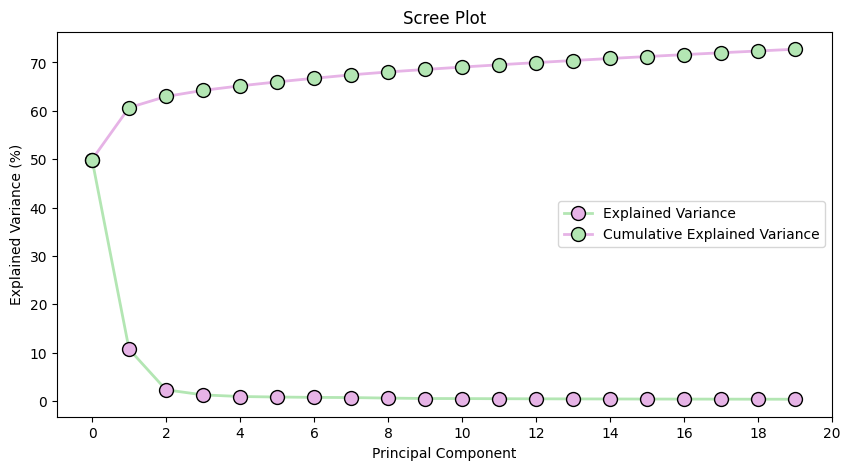

In [68]:
# PCA for 20 components for plotting
pca = PCA(n_components=20).fit(target_acts)
X_pca = pca.transform(target_acts)[:,:2]
scree = 100 * pca.explained_variance_ratio_
scree_cum = 100*pca.explained_variance_ratio_.cumsum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(scree, 'o-', linewidth=2, color=[.7,.9,.7,1], mfc=[.9,.7,.9,1], mec = 'k',ms=10, label='Explained Variance')
plt.plot(scree_cum, 'o-', linewidth=2, color=[.9,.7,.9,1], mfc=[.7,.9,.7,1], mec = 'k',ms=10, label='Cumulative Explained Variance')
plt.legend()
plt.title('Scree Plot')
plt.xticks(range(0, 21, 2))
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.show()

# Visualize the average trajectories

In [62]:
aveTrajectories = np.zeros((num_layers,2,2))

for i in range(num_layers):
  aveTrajectories[i,:,0] = X_pca[(lookup[:,0]==i) & (lookup[:,1]==1),:].mean(axis=0) # nouns
  aveTrajectories[i,:,1] = X_pca[(lookup[:,0]==i) & (lookup[:,1]==2),:].mean(axis=0) # adjectives

# calculate distances between noun and adjective tokens
noun_pts = aveTrajectories[:,:,0]
adj_pts  = aveTrajectories[:,:,1]
pos_distances = np.linalg.norm( noun_pts-adj_pts ,axis=1)

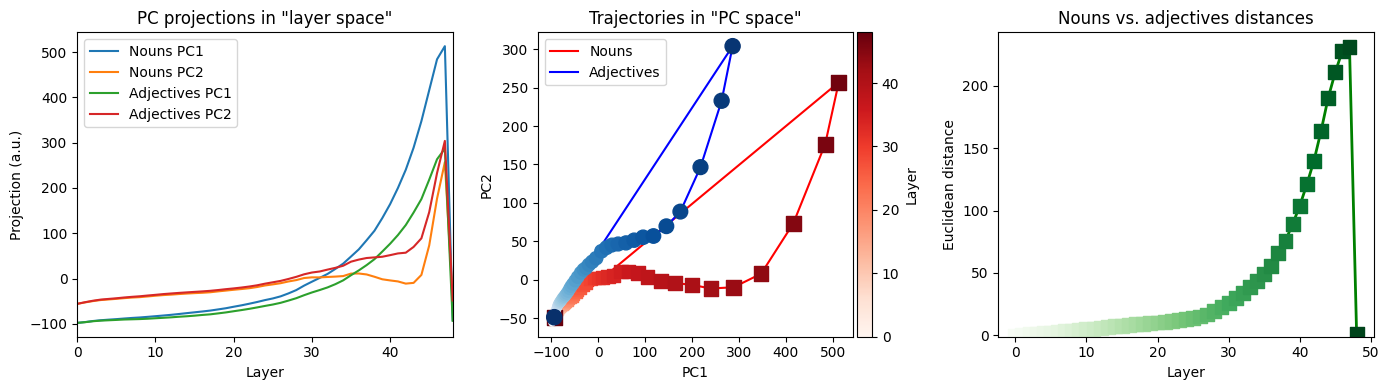

In [63]:
fig,axs = plt.subplots(1,3,figsize=(14,4))

### plot the trajectories in "layer space"
axs[0].plot(aveTrajectories[:,0,0],label='Nouns PC1')
axs[0].plot(aveTrajectories[:,1,0],label='Nouns PC2')
axs[0].plot(aveTrajectories[:,0,1],label='Adjectives PC1')
axs[0].plot(aveTrajectories[:,1,1],label='Adjectives PC2')
axs[0].set(xlim=[0,num_layers-1],xlabel='Layer',ylabel='Projection (a.u.)',
           title='PC projections in "layer space"')
axs[0].legend()


### trajectories in PC state-space
# plot the trajectory for nouns
axs[1].plot(aveTrajectories[:,0,0],aveTrajectories[:,1,0],'r',zorder=-3,label='Nouns')
h = axs[1].scatter(aveTrajectories[:,0,0],aveTrajectories[:,1,0],marker='s',
               s=np.linspace(20,120,num_layers),c=np.arange(num_layers),cmap='Reds')

# repeat for adjectives
axs[1].plot(aveTrajectories[:,0,1],aveTrajectories[:,1,1],'b',zorder=-3,label='Adjectives')
axs[1].scatter(aveTrajectories[:,0,1],aveTrajectories[:,1,1],marker='o',
               s=np.linspace(20,120,num_layers),c=np.arange(num_layers),cmap='Blues')

axs[1].set(xlabel='PC1',ylabel='PC2',title='Trajectories in "PC space"')
axs[1].legend()
fig.colorbar(h,ax=axs[1],label='Layer',pad=.01)



### show distances
axs[2].plot(pos_distances,'g',linewidth=2,zorder=-6)
axs[2].scatter(range(num_layers),pos_distances,marker='s',s=100,c=np.arange(num_layers),cmap='Greens')
axs[2].set(xlabel='Layer',ylabel='Euclidean distance',title='Nouns vs. adjectives distances',ylim=[-1,None])

plt.tight_layout()
plt.show()

# Calculate trajectory distances

In [64]:
# vectorized for efficiency
dx = aveTrajectories[1:,0,0] - aveTrajectories[:-1,0,0]
dy = aveTrajectories[1:,1,0] - aveTrajectories[:-1,1,0]

distancesV = np.sqrt( dx**2 + dy**2 )

In [65]:
distancesV

array([  3.6851979 ,   3.654731  ,   2.90728133,   1.82086215,
         1.79886178,   2.05496858,   1.78115359,   1.42501364,
         2.04131915,   2.17245406,   2.02912291,   1.8437731 ,
         2.22378186,   2.18149125,   2.0700821 ,   1.99285047,
         2.28349439,   3.20037446,   3.1636122 ,   3.75920434,
         3.5295352 ,   4.00087041,   4.61776652,   5.36484145,
         4.38570318,   5.32307172,   7.52756634,   7.92595084,
        10.86146861,   8.78931283,   8.45435927,   8.76967769,
        11.10861575,  11.70280631,  16.6063396 ,  15.87192764,
        20.26703467,  21.50148973,  28.50162539,  30.84670794,
        35.78042203,  40.42420798,  48.70834613,  61.30617206,
        94.46063909, 123.7281109 ,  85.43004451, 677.77203651])

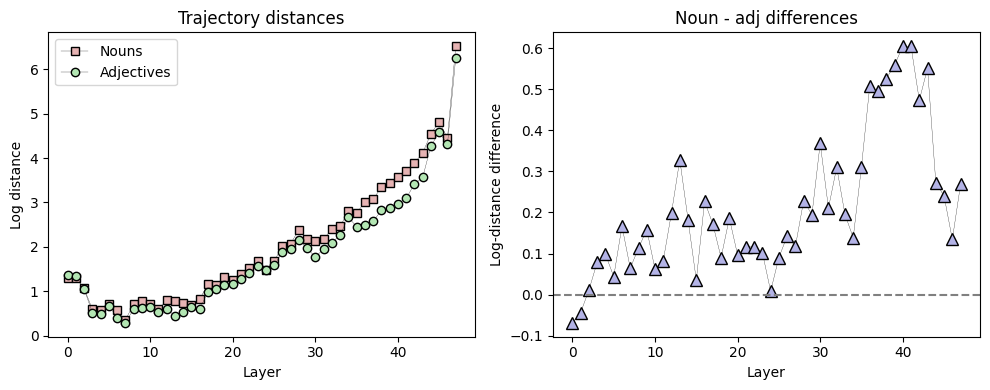

In [66]:
# initialize
distances = np.zeros((num_layers-1,2))

# using for-loops for clarity
for i in range(1,num_layers):
  for j in range(2):

    # x points
    x1 = aveTrajectories[i-1,0,j]
    x2 = aveTrajectories[i,0,j]

    # y points
    y1 = aveTrajectories[i-1,1,j]
    y2 = aveTrajectories[i,1,j]

    # euclidean distances
    distances[i-1,j] = np.sqrt( (x1-x2)**2 + (y1-y2)**2 )


# plotting
_,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(np.log(distances[:,0]),'ks-',markerfacecolor=[.9,.7,.7],linewidth=.2,label='Nouns')
axs[0].plot(np.log(distances[:,1]),'ko-',markerfacecolor=[.7,.9,.7],linewidth=.2,label='Adjectives')
axs[0].legend()
axs[0].set(xlabel='Layer',ylabel='Log distance',title='Trajectory distances')

axs[1].plot(np.log(distances[:,0]/distances[:,1]),'k^-',linewidth=.2,markersize=9,markerfacecolor=[.7,.7,.9])
axs[1].axhline(0,linestyle='--',color='gray')
axs[1].set(xlabel='Layer',ylabel='Log-distance difference',title='Noun - adj differences')

plt.tight_layout()
plt.show()